# 数据集形态报告：S&P 500 价格指数

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'

# 读取数据
df = pd.read_csv('../dataset/stock_data_sp500_paper.csv')
price_data = df.iloc[1:, 2:].astype(float)
stocks = price_data.shape[1]
days = price_data.shape[0]

# 提取日期范围
dates = df.iloc[1:, 1].tolist()
start_date = dates[0]
end_date = dates[-1]

print(f"股票数量: {stocks}")
print(f"交易日数量: {days}")
print(f"日期范围: {start_date} 到 {end_date}")
print(f"价格范围: [{price_data.min().min():.2f}, {price_data.max().max():.2f}]")

股票数量: 350
交易日数量: 1260
日期范围: 2013-02-08 到 2018-02-08
价格范围: [13.19, 376.24]


## 数据预览（前5行，前5列）

In [6]:
df.iloc[:5, :5]

,index,date,CSX,EFX,MO
0,0,industry,stock,stock,stock
1,1,2013-02-08,100.0,100.0,100.0
2,2,2013-02-11,101.5475609486244,99.4780366784271,100.08647457902957
3,3,2013-02-12,102.04824652448069,98.90808613763564,100.02881128717569
4,4,2013-02-13,102.56030342739834,98.48362931966626,100.08647301297178


## 预处理流程
1. 原始数据：Kaggle S&P 500 日线（2013-2018）
2. 提取 Close 价格，删除起始日期不一致的股票
3. 转换为价格指数（起点 = 100）
4. SMA-10 平滑
5. 缺失值清洗（<10% 删除，其余填充）

## 价格走势可视化（随机抽取50只）

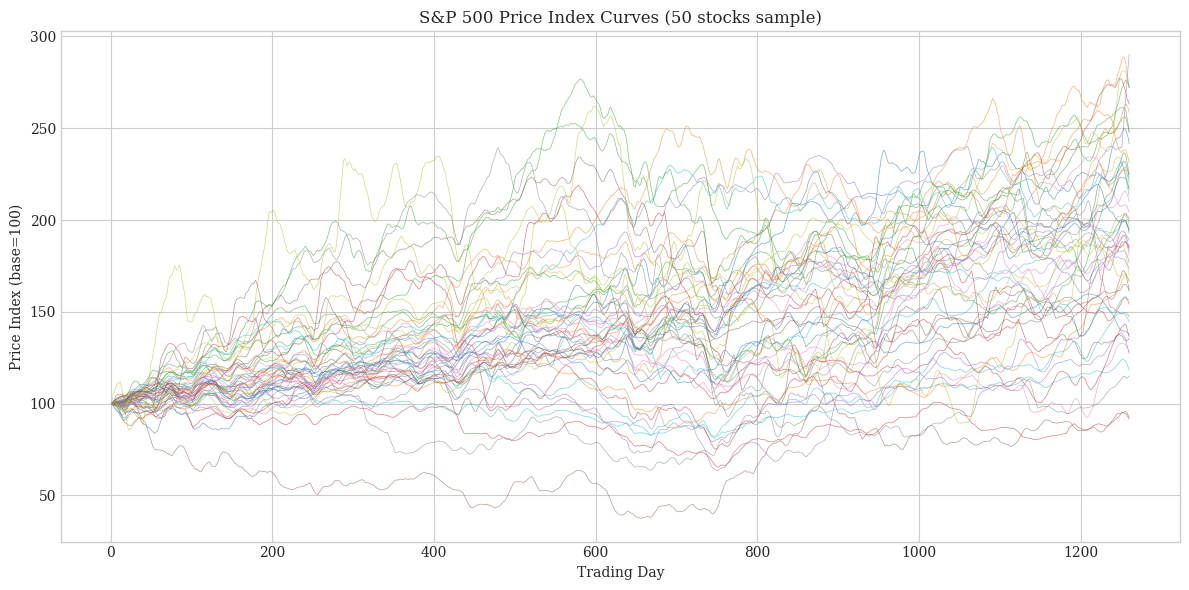

In [7]:
# 随机抽取50只股票画图
sample_stocks = np.random.choice(price_data.columns, 50, replace=False)
plt.figure(figsize=(12, 6))
for col in sample_stocks:
    plt.plot(price_data.index, price_data[col], linewidth=0.5, alpha=0.6)
plt.title('S&P 500 Price Index Curves (50 stocks sample)')
plt.xlabel('Trading Day')
plt.ylabel('Price Index (base=100)')
plt.tight_layout()
plt.savefig('price_curves_sample.png', dpi=150)
plt.show()